<a href="https://colab.research.google.com/github/sitiirma-data/customer-churn-analysis-python/blob/main/customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Description**

```
ABOUT DATA
----------
A fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3.

COLUMNS EXPLANATION
-------------------
CustomerID: A unique ID that identifies each customer.

Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

Country: The country of the customer’s primary residence.

State: The state of the customer’s primary residence.

City: The city of the customer’s primary residence.

Zip Code: The zip code of the customer’s primary residence.

Lat Long: The combined latitude and longitude of the customer’s primary residence.

Latitude: The latitude of the customer’s primary residence.

Longitude: The longitude of the customer’s primary residence.

Gender: The customer’s gender: Male, Female

Senior Citizen: Indicates if the customer is 65 or older: Yes, No

Partner: Indicate if the customer has a partner: Yes, No

Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

Tenure Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

Device Protection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.
```

1. Visualiasi untuk menemukan perbedaan persentase dari `customer yang churn` dan `customer yang tidak churn`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://drive.google.com/uc?id=1-1qxHu-wbOcT4oTFd3nszx77Glnnp5P2')

In [2]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Untuk mengetahui adanya data yang kosong atau tidak. Dan dari hasil di atas menyatakan bahwa semua kolom sudah terisi penuh sesuai total baris. Sedangkan untuk kolom Churn Reason data yang kosong tidak perlu diisi karena datanya berupa object.

In [4]:
percent_of_churn = (df['Churn Label'].value_counts(normalize=True)*100).reset_index()
percent_of_churn

,Churn Label,proportion
0,No,73.463013
1,Yes,26.536987


Dari rumus value_counts dapat diketahui jumlah customer yang akan churn (membatalkan langganan). No berarti customer yang tidak churn yaitu customer yang terus berlangganan sebanyak 73,46% dan Yes berarti customer yes churn, customer yang berhenti berlangganan  quarter ini sebanyak 26,53%.  

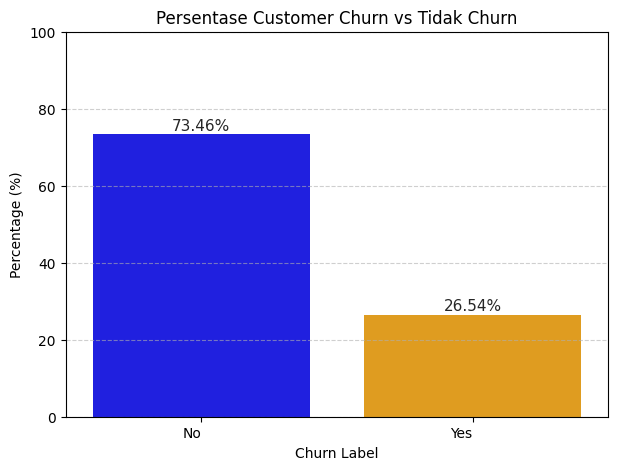

In [5]:
# Create the bar chart with sorted values

plt.figure(figsize=(7, 5))
# plt.figure(figsize=(tinggi, lebar))

# Persentase Customer yang churn dan tidak churn
ax = sns.barplot(data=percent_of_churn, x='Churn Label', y='proportion',hue ='Churn Label', palette = ['blue', 'orange'], legend = False)

# Set the title and labels
plt.title('Persentase Customer Churn vs Tidak Churn')
plt.xlabel('Churn Label')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# mempercantik
sns.set_style("whitegrid")
plt.xticks(rotation=0, horizontalalignment='right')
plt.ylim(bottom=0, top=100)
# Set the background color
plt.gca().set_facecolor('white')

# menambahkan label persentase
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            height + 1,
            f'{height:.2f}%',
            ha='center',
            fontsize=11)


Dari Barplot diatas dapat disimpulkan bahwa customer mayoritas tidak melakukan Churn (73,46%) dan yang melakukan Churn hanya sebesar 26.54%. Berarti, tingkat retensi pelanggan masih relatif baik, namun perusahaan perlu menganalisa penyebab lebih dari seperempat pelanggan berhenti berlangganan dan merancang strategi retensi seperti peningkatan pelayanan, penawaran promo atau program loyalitas pelanggan.



2.   Visualisasi untuk melihat hubungan antara `jumlah bulan yang telah dihabiskan customer` di perusahaan pada akhir kuartal dan `total tagihan customer`

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Jumlah bulan yang telah dihabiskan customer merupakan Tenure Months berdasarkan data description dan total tagihan customer merupakan Total Charges. Dari info diatas Tenure months data type nya integer dan Total Charges data type nya object. Kedua kolom ini harus sama-sama jenis numerikal karena kita ingin melihat hubungan antara dua angka tersebut.

In [7]:
df['Total Charges'].head()

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3


In [8]:
df['Total Charges'].value_counts().head(20)

,count
Total Charges,
20.2,11
,11
19.75,9
20.05,8
19.65,8
19.9,8
45.3,7
19.55,7
20.15,6


Dari hasil value counts untuk kolom Total Charges dapat diketahui ada 11 baris yang berisi missing value. Karena jumlahnya hanya sedikit baris ini dapat dihilangkan tanpa mempengaruhi hasil analisa. Baris yang kosong biasanya berarti bahwa customer belum memiliki tagihan.

In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

Data diubah menjadi numerikal dan string kosong diubah menjadi NaN dan selanjutnya akan dilakukan penanganan missing value.

In [10]:
df = df.dropna(subset=['Total Charges'])

11 data yang awalnya berupa string kosong sudah dihapus. Data dihapus karena jumlahnya hanya sedikit dan penghapusan tidak akan mempengaruhi analisa.

In [11]:
df['Total Charges'].isnull().sum()

np.int64(0)

Data cleaning berhasil

In [12]:
df['Total Charges'].dtype

dtype('float64')

Tipe data di cek dan hasilnya Kolom Total Charges sudah berubah menjadi numerikal

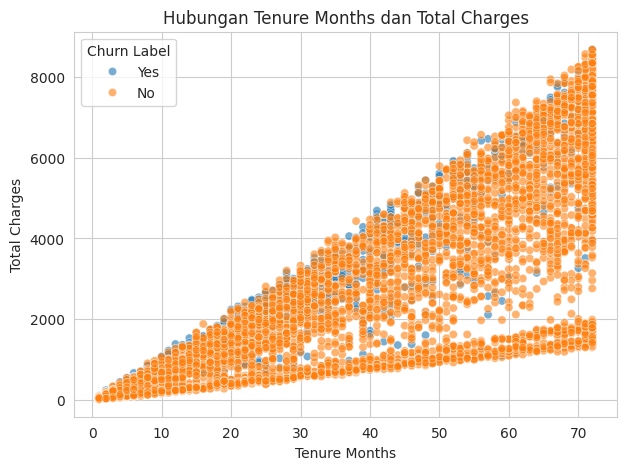

In [13]:
# Create the scatter plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Tenure Months',
    y='Total Charges',
    hue='Churn Label',
    alpha=0.6
)

plt.title('Hubungan Tenure Months dan Total Charges')
plt.xlabel('Tenure Months')
plt.ylabel('Total Charges')

plt.show()

Dari visualisasi di atas terlihat bahwa Total Charges (Total Tagihan Customer) berkorelasi positif dengan Tenure Months (Jumlah bulan yang dihabiskan customer). Semakin lama customer berlangganan maka semakin tinggi total tagihannya. Dari visualisasi di atas terdapat dua warna yang berbeda warna oranye menunjukkan customer yang masih berlanggan lebih banyak dibandingkan customer yang tidak melanjutkan langganan (titik biru) berdasarkan kolom Churn Label.

3.   Visualisasi untuk melihat 5 `kota` teratas yang customernya melakukan churn dan tidak melakukan churn

In [14]:
top_city = df['City'].value_counts().head(5).index
top_city

Index(['Los Angeles', 'San Diego', 'San Jose', 'Sacramento', 'San Francisco'], dtype='object', name='City')

Melihat 5 kota mana saja customer terbesar yang berlangganan berasal.

In [15]:
top5_city = df[df['City'].isin(top_city)]
top5_city['City'].value_counts()

,count
City,
Los Angeles,304
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104


Filter dataset hanya untuk 5 kota teratas

In [16]:
churn_city = top5_city.groupby(['City','Churn Label']).size().reset_index(name='Jumlah')
churn_city

,City,Churn Label,Jumlah
0,Los Angeles,No,214
1,Los Angeles,Yes,90
2,Sacramento,No,82
3,Sacramento,Yes,26
4,San Diego,No,100
5,San Diego,Yes,50
6,San Francisco,No,73
7,San Francisco,Yes,31
8,San Jose,No,83
9,San Jose,Yes,29


Mengubah menjadi data frame

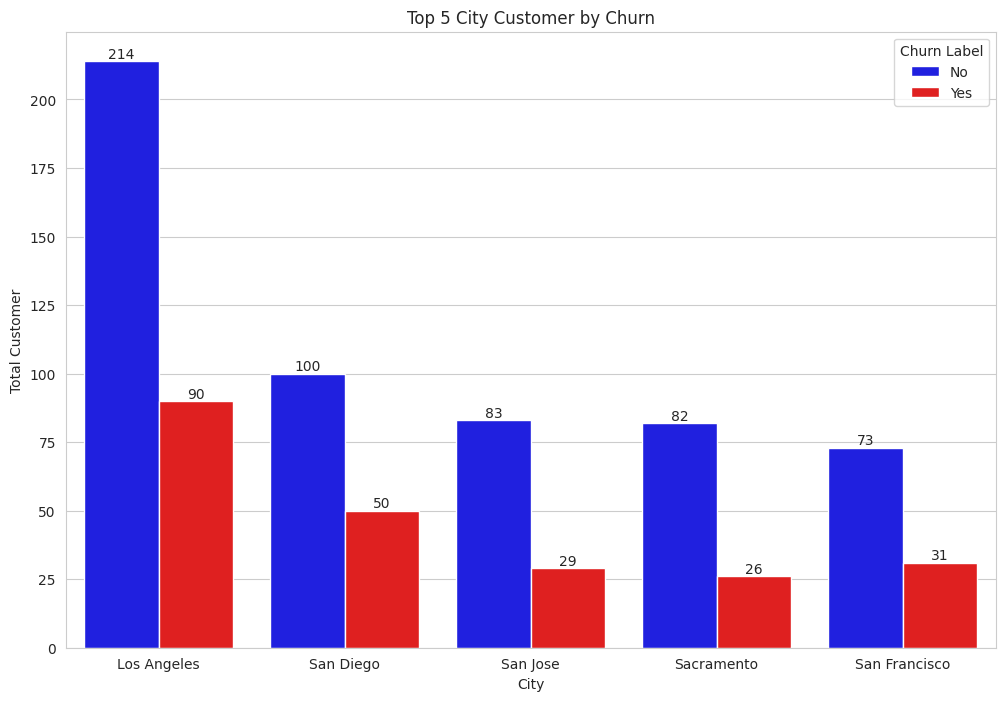

In [17]:
# mengurutkan kota dari nilai terbesar
order_city = churn_city.groupby('City')['Jumlah'].sum().sort_values(ascending=False).index

# create multiple bar chart
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=churn_city, x='City', y='Jumlah', hue='Churn Label', order=order_city, palette={'No':'Blue', 'Yes':'Red'})

# Adding number labels to each bar
for s in ax.containers:
    ax.bar_label(s, fmt='%.0f')

plt.title('Top 5 City Customer by Churn')
plt.xlabel('City')
plt.ylabel('Total Customer')
plt.legend(title='Churn Label')
plt.xticks(rotation=0)

plt.show()

Dari visualisasi tersebut, Los Angeles merupaka kota dengan total customer terbesar dari segi churn maupun tidak churn. Kota San Diego memiliki proporsi churn terbesar yaitu 50% dari tidak churnnya dibanding 4 kota lain. Dan kota Sacramento memiliki jumlah churn paling rendah diantara 5 kota-kota teratas.

4. Visualisasi untuk melihat persebaran data dari tenure months untuk masing-masing churn label


In [18]:
def check_plot(df):
  # fungsi mengambil kerangka data (df) dan
  # variabel yang diminati sebagai argumen

  # menentukan ukuran gambar
  plt.figure(figsize=(16,4))

  #histogram
  plt.subplot(1, 2, 1)
  sns.histplot(data = df, x = 'Tenure Months', hue = 'Churn Label', bins=30, kde = True)
  plt.title('Distribution of Tenure Months by Churn Label')

  #boxplot
  plt.subplot(1, 2, 2)
  sns.boxplot(data=df, x='Churn Label', y='Tenure Months',hue = 'Churn Label', palette={'No':'blue','Yes':'red'}, legend = False)
  plt.title('Distribution of Tenure Months by Churn Label')
  plt.xlabel('Churn Label')
  plt.ylabel('Tenure Months')

  plt.show()

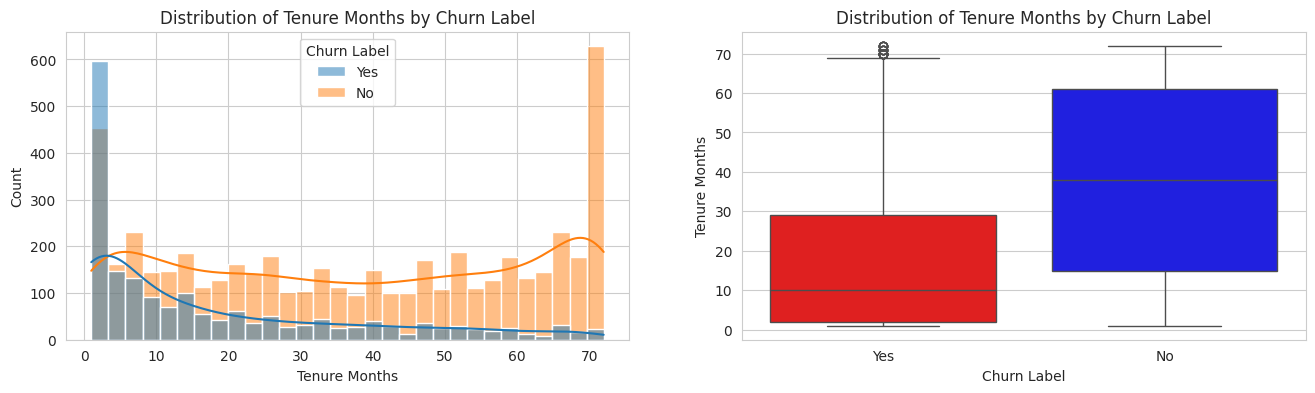

In [19]:
check_plot(df)

Berdasarkan visualisasi di atas pada histogram terlihat bahwa pada awal awal bulan berlangganan tingkat churn customer sangat tinggi namun berkurang seiring bertambahnya bulan untuk berlangganan. Sama halnya pada histogram pada boxplot terlihat bahwa median tenure months pada customer yang melakukan churn lebih rendah dibandingkan pada boxplot customer yang tidak melakukan churn. Kesimpulannya customer yang baru berlangganan lebih rentan melakukan churn sedangkan customer yang sudah lama berlangganan cenderung lebih loyal.

5. Jelaskan insight dan saran action yang Anda dapatkan pada setiap visualisasi

###**1. Persentase Customer Churn**

**Insight**

Pesentase customer yang tidak melakukan churn (73,46%) jauh lebih besar dibandingkan dengan customer yang melakukan churn (26,54%). Meskipun nilainya masih jauh dibawah customer yang tidak melakukan churn. Potensi kehilangan customer lebih banyak sangat mungkin terjadi di waktu yang akan datang. Sehingga perlu dilakukan strategi untuk mempertahankan loyalitas customer.

**Saran Action**

Strategi yang dapat dilakukan oleh perusahaan adalah:
- Loyalty program bagi customer yang sudah berlangganan lama dan tidak melakukan churn.
- Peningkatan kualitas layanan baik dari segi fasilitas atau pelayanan jasa.
- Penawaran khusus bagi customer yang berpotensi churn, misalnya promo untuk customer baru di beberapa bulan awal berlangganan.

###**2. Hubungan Tenure Months dan Total Charges**
**Insight**

Total Charges (Total Tagihan Customer) berkorelasi positif dengan Tenure Months (Jumlah bulan yang dihabiskan customer). Semakin lama customer berlangganan maka semakin tinggi total tagihannya.

**Saran Action**

Customer dengan tenure yang tinggi merupakan segmen bernilai tinggi, sehingga perusahaan dapat menerapkan program loyalitas atau upselling untuk mempertahankan loyalitasnya.

###3. Top 5 City Customer by Churn
**Insight**

Los Angeles merupakan kota dengan total customer terbesar dari segi churn maupun tidak churn. Kota San Diego memiliki proporsi churn terbesar yaitu 50% dari tidak churnnya dibanding 4 kota lain. Dan kota Sacramento memiliki jumlah churn paling rendah diantara 5 kota-kota teratas. Hal ini menunjukkan kota dengan basis customer yang besar juga memiliki risiko churn yang lebih tinggi.

**Saran Action**
Perusahaan dapat memfokuskan strategi retensi pada kota dengan jumlah customer besar melalui:
- Peningkatan layanan
- Promosi regional
- Analisis faktor churn pada wilayah yang rentan churn.

###4. Distribution of Tenure Months by Churn
**Insight**

Customer yang melakukan churn umumnya memiliki tenure yang lebih rendah. Sedangkan customer yang tidak melakukan churn memiliki tenure yang lebih tinggi. Hal ini menunjukkan customer baru memiliki risiko churn yang lebih tinggi.

**Saran Action**
- Onboarding (membantu customer baru memahami dan mulai menggunakan produk atau layanan dengan mudah)
- Dukungan pelanggan yang responsif
- Promosi khusus bagi customer baru

###Kesimpulan
Hasil analisa menunjukkan bahwa churn lebih banyak terjadi pada customer dengan tenure rendah dan pada wilayah dengan jumlah customer besar. Sehingga perlu dilakukan strategi untuk mempertahankan loyalitas dengan meningkatkan retensi customer baru dan memperkuat hubungan dengan customer lama yang terus berlangganan.